In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import faiss
import pickle
import numpy as np
import ast
from collections import Counter
from tqdm import tqdm
from scipy.stats import fisher_exact

In [2]:
foldseek_cluster = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/2-repId_isDark_nMem_repLen_avgLen_repPlddt_avgPlddt_LCAtaxId.tsv", sep="\t",
                                names= ["repID", "isDark", "nMem", "repLen", "avgLen", "repPlddt", "avgPlddt", "LCAtaxID"])

In [3]:
len(foldseek_cluster['repID'].unique())

2302908

In [4]:
human_proteins = os.listdir("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/UP000005640_9606_HUMAN_v4")
human_proteins = set([x.split("-")[1] for x in human_proteins])
foldseek_cluster['is_human'] = foldseek_cluster['repID'].isin(human_proteins)
len(human_proteins)

20504

In [6]:
uniprot_annotated_3 = pd.read_csv("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_annotation_score_3_2024_11_27.tsv", sep="\t")
uniprot_annotated_4 = pd.read_csv("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_annotation_score_4_2024_11_27.tsv", sep="\t")
uniprot_annotated_5 = pd.read_csv("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_annotation_score_5_2024_11_25.tsv", sep="\t")

/tmp/ipykernel_3488064/1596002663.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  uniprot_annotated_3 = pd.read_csv("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_annotation_score_3_2024_11_27.tsv", sep="\t")


In [17]:
annotated_uniprot_entries = np.concatenate([uniprot_annotated_3['Entry'],uniprot_annotated_4['Entry'],uniprot_annotated_5['Entry']])
len(annotated_uniprot_entries), len(set(annotated_uniprot_entries))

(16246238, 16244615)

In [15]:
annotated_foldseek = foldseek_cluster[(foldseek_cluster['repID'].isin(annotated_uniprot_entries))]
len(annotated_foldseek)

12671

In [3]:
foldseek_cluster[(foldseek_cluster['isDark'] == 0) & (foldseek_cluster['avgPlddt'] > 90)]

,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
0,A0A6A4IZ81,0,4,386,387.250,89.69,91.1875,131567
16,A0A183W5C8,0,5,52,53.600,91.69,92.0620,131567
75,A0A806EWA9,0,4,68,67.250,90.06,91.2500,33958
82,A0A2C6LII4,0,476,206,223.962,86.88,91.8646,131567
132,A0A7Y8J0W5,0,4,555,483.250,93.12,93.0625,2
...,...,...,...,...,...,...,...,...
2302804,T5IAA2,0,517,289,297.563,95.44,91.7652,131567
2302841,A0A1G5MBP3,0,9,121,125.444,95.31,94.5922,2
2302848,A0A7F5RII7,0,3,77,81.000,94.25,93.0200,33317
2302860,A0A7X6XPF8,0,31,990,1034.230,81.88,91.1916,131567


In [5]:
foldseek_cluster[(foldseek_cluster['isDark'] == 1) & (foldseek_cluster['avgPlddt'] > 90)]

,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
86,A0A2J6J618,1,2,99,99.5000,89.06,91.4700,2
212,A0A7C5CMB3,1,5,210,209.0000,90.62,90.6620,131567
236,A0A656SEC2,1,3,64,63.3333,95.12,95.8733,2
260,A0A847M5J9,1,2,56,56.0000,94.50,94.5000,2
263,B6VW07,1,2,89,92.0000,93.31,91.8750,2
...,...,...,...,...,...,...,...,...
2302642,A0A662TDH4,1,2,68,69.0000,95.00,95.5000,2157
2302727,X8F7I6,1,3,44,44.6667,95.64,93.3167,2
2302766,A0A350RK83,1,2,131,137.5000,91.88,90.0350,2
2302776,A0A1X1Q380,1,8,64,64.6250,95.75,94.1563,1783272


In [6]:
bright_rep_ids = foldseek_cluster[(foldseek_cluster['isDark'] == 0) & (foldseek_cluster['avgPlddt'] > 90)]['repID'].tolist()
downloaded = os.listdir("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/is_bright_90_plddt/AF2DB_structures/")
downloaded = [x.replace(".pdb", "") for x in downloaded if x.endswith(".pdb")]
bright_rep_ids = list(set(bright_rep_ids) - set(downloaded))
print("To download: ", len(bright_rep_ids))
# for i in range(30):
#     with open(f'/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/is_bright_90_plddt/AF2DB_structures/foldseek-cluster-plddt-90-bright-prot-{i}.txt', 'w') as f:
#         for rep_id in bright_rep_ids[i::20]:
#             f.write(rep_id + '\n')

To download:  0


In [13]:
import glob
bright_rep_ids = foldseek_cluster[(foldseek_cluster['isDark'] == 0) & (foldseek_cluster['avgPlddt'] > 90)]['repID'].tolist()
downloaded = glob.glob("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/is_bright_90_plddt/AF2DB_structures_pesto/*_i0.pdb")
downloaded = [os.path.basename(x).replace("_i0.pdb", "") for x in downloaded if x.endswith(".pdb")]
bright_rep_ids = list(set(bright_rep_ids) - set(downloaded))
print("To download: ", len(bright_rep_ids))

# for i in range(5):
#     with open(f'/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/is_bright_90_plddt/AF2DB_structures/foldseek-cluster-plddt-90-bright-prot-part2-{i}.txt', 'w') as f:
#         for rep_id in bright_rep_ids[i::5]:
#             f.write(rep_id + '\n')

To download:  1423


In [7]:
foldseek_cluster[(foldseek_cluster['isDark'] == 1) & (foldseek_cluster['is_human'] == True)] 

,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID,is_human
71229,Q0VD83,1,4,1097,1147.500,41.21,36.3650,1437010,True
326466,Q8NEX6,1,3,87,90.000,78.09,74.6367,1437010,True
456464,Q9Y228,1,2,551,564.500,73.57,70.9750,117571,True
740686,Q0P6D6,1,6,951,888.167,49.78,47.8533,9347,True
967901,Q86UQ8,1,2,179,176.000,59.05,56.3200,2759,True
1188967,A8MXV6,1,2,281,269.500,53.79,49.4550,9606,True
1313668,Q75WM6,1,2,255,252.000,62.27,60.9150,1437010,True
1468079,Q99618,1,2,268,266.500,59.10,56.6450,32524,True
1532315,A0A096LP49,1,2,1063,1065.500,44.16,43.3900,314146,True
1668948,A0A1B0GTK4,1,2,181,189.500,64.61,56.3650,117571,True


In [8]:
rep_ids = foldseek_cluster[(foldseek_cluster['isDark'] == 1) & (foldseek_cluster['avgPlddt'] > 90)]['repID'].values

In [9]:
with open('foldseek-cluster-plddt-90-dark-prot.txt', 'w') as f:
    for rep_id in rep_ids:
        f.write(rep_id + '\n')

### helper function

In [10]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio.SeqIO.FastaIO import FastaWriter

def pdb_to_fasta(pdb_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    output = {}

    # Open the FASTA file for writing
    for model in structure:
        for chain in model:
            sequence = ""
            for residue in chain:
                # Ensure the residue is an amino acid
                if PDB.is_aa(residue, standard=True):
                    sequence += seq1(residue.get_resname())
            
            # Create a sequence record for the chain
            seq_record = SeqRecord(
                Seq(sequence),
                id=f"{structure_id}_{chain.id}",
                description=f"Chain {chain.id}"
            )

            output[seq_record.id] = str(seq_record.seq)
    return output

In [11]:
aas = [  # amino acids
        ('G', 'GLY'), ('A', 'ALA'), ('V', 'VAL'), ('L', 'LEU'),
        ('I', 'ILE'), ('F', 'PHE'), ('W', 'TRP'), ('Y', 'TYR'),
        ('D', 'ASP'), ('H', 'HIS'), ('N', 'ASN'), ('E', 'GLU'),
        ('K', 'LYS'), ('Q', 'GLN'), ('M', 'MET'), ('R', 'ARG'),
        ('S', 'SER'), ('T', 'THR'), ('C', 'CYS'), ('P', 'PRO') # 20 aa
        # ('U', 'SEC') # 21 aa for eukaryote
    ]

aas = dict(zip(range(4,4+len(aas)),[x[1] for x in aas]))
aas[2] = 'UNK'

# Annotate dark clusters

In [11]:
pesto_residues = pd.read_csv("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/protein_universe/PeSTo_residues.csv")
# pesto_residues['residue_starts'] = pesto_residues['residue_starts'].apply(ast.literal_eval)
pesto_residues['residues'] = pesto_residues['residues'].apply(ast.literal_eval)
pesto_residues['num_residues'] = pesto_residues['residues'].apply(len)
pesto_residues = pesto_residues.set_index(['protein', 'binder_type'])
pesto_residues

pdb_file_path  \
protein    binder_type                                                       
A0A2J6J618 protein       /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           nucleic_acid  /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           ion           /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           ligand        /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           lipid         /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
...                                                                    ...   
A0A6F8XIP7 protein       /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           nucleic_acid  /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           ion           /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           ligand        /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   
           lipid         /n/holystore01/LABS/mzitnik_lab/Lab/afang/prot...   

                                                            residue_starts  \
protein    binder_type                                                       
A0A2J6J618 protein                                           [ 0  9 21 30]   
           nucleic_acid                                              [0 9]   
           ion                                                          []   
           ligand                                                       []   
           lipid                                                        []   
...                                                                    ...   
A0A6F8XIP7 protein       [  0   9  20  26  40  47  56  64  73  81  92 1...   
           nucleic_acid                                                 []   
           ion                                                          []   
           ligand                                                       []   
           lipid                                                       [0]   

                                                                  residues  \
protein    binder_type                                                       
A0A2J6J618 protein       [(A, 5, LYS, ), (A, 65, TYR, ), (A, 76, GLU, )...   
           nucleic_acid                   [(A, 26, LYS, ), (A, 80, ILE, )]   
           ion                                                          []   
           ligand                                                       []   
           lipid                                                        []   
...                                                                    ...   
A0A6F8XIP7 protein       [(A, 3, GLN, ), (A, 4, ARG, ), (A, 5, CYS, ), ...   
           nucleic_acid                                                 []   
           ion                                                          []   
           ligand                                                       []   
           lipid                                          [(A, 40, SER, )]   

                         num_residues  
protein    binder_type                 
A0A2J6J618 protein                  4  
           nucleic_acid             2  
           ion                      0  
           ligand                   0  
           lipid                    0  
...                               ...  
A0A6F8XIP7 protein                 25  
           nucleic_acid             0  
           ion                      0  
           ligand                   0  
           lipid                    1  

[74460 rows x 4 columns]

In [74]:
# def get_mean_block_embedding(item):
#     global_indexes = [i for i,x in enumerate(item['block_id']) if x == 3]
#     end_segment0 = global_indexes[-1] if len(global_indexes) == 2 else len(item['block_id'])
#     return np.mean(item['block_embedding'][:end_segment0], axis=0)

def get_mean_block_embedding(item):
    return item['graph_embedding']

In [13]:
embeddings_dir = "/n/holyscratch01/mzitnik_lab/afang/InteractNN_embeddings/prot_interface_version_16_epoch16_step97495/"
query_data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/"

## protein-nucleic

In [12]:
rna_central_to_pdb = pd.read_csv("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/rna_case_studies/go_terms/pdb.tsv", sep="\t", header=None, names=['RNACentral_id', 'PDB_chain_id', 'NCBI_taxonomy_ID', 'RNA_type'], usecols=[0, 2, 3, 4])
rna_central_to_pdb['RNACentral_id'] = rna_central_to_pdb['RNACentral_id'].astype(str) + '_' + rna_central_to_pdb['NCBI_taxonomy_ID'].astype(str)
rna_central_to_pdb['PDB_id'] = rna_central_to_pdb['PDB_chain_id'].apply(lambda x: x.split('_')[0])

In [13]:
pdb_to_rna_type = dict(rna_central_to_pdb[['PDB_id', 'RNA_type']].itertuples(index=False))

In [14]:
query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_80_nucleic_acid.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)

query_data_file = f"{query_data_dir}/is_dark_90_plddt_PeSTo_80_nucleic_acid.pkl"
with open(query_data_file, 'rb') as f:
    query_dataset = pickle.load(f)
query_dataset = {x['id']:x for x in query_dataset}

query_graph_embeddings = np.array([get_mean_block_embedding(x) for x in query_embeddings])
len(query_graph_embeddings)

1368

In [15]:
pdb_embeddings_file = f"{embeddings_dir}/PRNA_nonredund.pkl"
with open(pdb_embeddings_file, 'rb') as f:
    pdb_embeddings = pickle.load(f)

pdb_graph_embeddings = np.array([get_mean_block_embedding(x) for x in pdb_embeddings])


dna_embeddings_file = f"{embeddings_dir}/PDNA_nonredund.pkl"
with open(dna_embeddings_file, 'rb') as f:
    dna_embeddings = pickle.load(f)

dna_graph_embeddings = np.array([get_mean_block_embedding(x) for x in dna_embeddings])

In [16]:
rna_central_files = [f"/n/netscratch/mzitnik_lab/Lab/afang/RNA_case_studies/RNACentral/processed/embeddings/PRNA_{i}.pkl" for i in range(12)]
rna_central_embeddings = []
for rna_central_file in rna_central_files:
    with open(rna_central_file, 'rb') as f:
        rna_central_embeddings.extend(pickle.load(f))
rna_central_graph_embeddings = np.array([get_mean_block_embedding(x) for x in rna_central_embeddings])

In [17]:
embeddings = np.concatenate([dna_graph_embeddings, pdb_graph_embeddings]) #, rna_central_graph_embeddings])
embeddings_list = dna_embeddings + pdb_embeddings # + rna_central_embeddings

embeddings_rna_types = ['DNA']*len(dna_embeddings) + [pdb_to_rna_type.get(x['id'][:4].upper(), None) for x in pdb_embeddings] #+rna_central_embeddings]

In [18]:
faiss_index = faiss.IndexFlatIP(embeddings.shape[1])
faiss_index.add(embeddings)

k = 10
D, I = faiss_index.search(query_graph_embeddings, k)

In [19]:
from collections import Counter
Counter(I.flatten()).most_common(10)

[(2885, 81),
 (4904, 73),
 (5622, 72),
 (625, 68),
 (2670, 67),
 (624, 67),
 (5436, 64),
 (4891, 64),
 (1092, 59),
 (5318, 58)]

In [20]:
query_results = []
for query, dist, neigh_idx in tqdm(zip(query_embeddings, D, I), total=len(query_embeddings)):
    neigh_rna_types = [embeddings_rna_types[i] for i in neigh_idx]
    query_result = {
        'dist': np.mean(dist), 
        'query_id': query['id'],
    }
    for rank, i in enumerate(neigh_idx):
        query_result[f'{rank}_PDB_id'] = embeddings_list[i]['id']
    query_results.append(query_result)

100%|██████████| 1368/1368 [00:00<00:00, 60231.86it/s]


In [21]:
for res in sorted(query_results, key=lambda x: -x['dist'])[:20]:
    print(res['dist'], res['query_id'], res['0_PDB_id'], res['1_PDB_id'], res['2_PDB_id'], res['3_PDB_id'], res['4_PDB_id'])

0.0014626265 A0A0K2H329 3s4g_1.pdb_3s4g_1_RNA_B55&C55.pdb 3s4g_1.pdb_3s4g_1_RNA_B57&C57.pdb 3s4g_1.pdb_3s4g_1_RNA_B38&C38.pdb 3s4g_1.pdb_3s4g_1_RNA_B24&C24.pdb 3s4g_1.pdb_3s4g_1_RNA_B44&C44.pdb
0.0018508673 A0A3B6Y1P7 3ra4_3.pdb_3ra4_3_DNA_B5.pdb 3ra4_6.pdb_3ra4_6_DNA_B5.pdb 1vtm_1.pdb_1vtm_1_RNA_A1.pdb 1vtm_3.pdb_1vtm_3_RNA_A.pdb 3ra4_4.pdb_3ra4_4_DNA_B2.pdb
0.0018810511 A0A2A4YD14 4xbf_1.pdb_4xbf_1_RNA_C3.pdb 4xbf_1.pdb_4xbf_1_RNA_C4.pdb 4xbf_1.pdb_4xbf_1_RNA_C1.pdb 1rmv_1.pdb_1rmv_1_RNA_A46.pdb 1rmv_1.pdb_1rmv_1_RNA_A30.pdb
0.0019028902 J5VY80 1laj_4.pdb_1laj_4_RNA_A24.pdb 1laj_6.pdb_1laj_6_RNA_A24.pdb 1laj_6.pdb_1laj_6_RNA_A10.pdb 1laj_6.pdb_1laj_6_RNA_A3.pdb 1laj_3.pdb_1laj_3_RNA_A3.pdb
0.0019150854 A0A7T0BUT0 5mjv_4.pdb_5mjv_4_RNA_D6.pdb 5mjv_4.pdb_5mjv_4_RNA_D24.pdb 1rmv_1.pdb_1rmv_1_RNA_A12.pdb 1rmv_1.pdb_1rmv_1_RNA_A9.pdb 1rmv_1.pdb_1rmv_1_RNA_A11.pdb
0.0019885898 B9P0D1 6v4x_1.pdb_6v4x_1_RNA_K&L.pdb 7otk_2.pdb_7otk_2_DNA_G&H.pdb 8fkp_1.pdb_8fkp_1_RNA_B.pdb 8fkt_1.pdb_8fkt_1_R

In [22]:
import random
rand_query_indexes = random.sample(range(len(query_graph_embeddings)), 50)
rand_embedding_indexes = random.sample(range(len(embeddings)), 50)

rand_distance = []
for rand_query_idx, rand_embedding_idx in zip(rand_query_indexes, rand_embedding_indexes):
    rand_distance.append(np.linalg.norm(query_graph_embeddings[rand_query_idx] - embeddings[rand_embedding_idx]))

print("Random distance between query and embedding", np.mean(rand_distance))

Random distance between query and embedding 1.0974114


## protein ligand

In [128]:
query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_80_ligand.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)

query_graph_embeddings = np.array([get_mean_block_embedding(x) for x in query_embeddings])
query_graph_embeddings.shape

(969, 32)

In [129]:
PL_embeddings_file = f"{embeddings_dir}/PL_nonredund.pkl"
with open(PL_embeddings_file, 'rb') as f:
    PL_embeddings = pickle.load(f)

PL_graph_embeddings = np.array([get_mean_block_embedding(x) for x in PL_embeddings])

In [130]:
AF3_ligands = ["ADP", "ATP", "GTP", "GDP", "FAD", "NAD", "NAP", "NDP", "HEM", "HEC", "PLM", "OLA", "MYR", "CIT", "CLA", "CHL", "BCL", "BCB"]
AF3_PL_embeddings = [x for x in PL_embeddings if x['id'].split("_")[4] in AF3_ligands]
AF3_PL_graph_embeddings = np.array([get_mean_block_embedding(x) for x in AF3_PL_embeddings])
AF3_PL_count = Counter([x['id'].split("_")[4] for x in AF3_PL_embeddings])
len(AF3_PL_embeddings), AF3_PL_count

(37764,
 Counter({'CLA': 16471,
          'ADP': 3819,
          'HEM': 2610,
          'ATP': 2524,
          'NAD': 2230,
          'FAD': 1991,
          'HEC': 1664,
          'NAP': 1318,
          'CHL': 1264,
          'BCL': 1234,
          'GDP': 997,
          'GTP': 718,
          'NDP': 638,
          'CIT': 141,
          'PLM': 54,
          'BCB': 50,
          'MYR': 29,
          'OLA': 12}))

In [131]:
faiss_index = faiss.IndexFlatIP(PL_graph_embeddings.shape[1])
faiss_index.add(PL_graph_embeddings)

k = 5
D, I = faiss_index.search(query_graph_embeddings, k)

In [132]:
query_results = []
for query, dist, neigh_idx in zip(query_embeddings, D, I):
    query_results.append([np.mean(dist), query['id'], [PL_embeddings[neigh]['id'] for neigh in neigh_idx]])

In [50]:
for res in sorted(query_results, key=lambda x: -x[0])[:20]:
    print(res)

[0.99971324, 'A0A1F6H1Z9', ['2dd4_1.pdb_2dd4_1_FRU_T.pdb', '1e6p_3.pdb_1e6p_3_GOL_R.pdb', '4yfb_2.pdb_4yfb_2_PAC_S.pdb', '4ufc_1.pdb_4ufc_1_GIV_D.pdb', '4q0v_1.pdb_4q0v_1_RUU_F1.pdb']]
[0.99968016, 'A0A6C0D213', ['2bue_1.pdb_2bue_1_RIO_C.pdb', '6e13_1.pdb_6e13_1_HKS_E1.pdb', '2efu_5.pdb_2efu_5_PHE_DA.pdb', '4bei_2.pdb_4bei_2_O4B_M.pdb', '4ewv_2.pdb_4ewv_2_APC_E.pdb']]
[0.99965227, 'A0A1G0I1F9', ['6v1y_1.pdb_6v1y_1_QNP_Q.pdb', '5jm8_3.pdb_5jm8_3_ATP_Q.pdb', '5jm8_1.pdb_5jm8_1_ATP_Q.pdb', '2wci_2.pdb_2wci_2_GSH_F.pdb', '6v1y_1.pdb_6v1y_1_QNP_V.pdb']]
[0.9996068, 'A0A1Z9VP26', ['8ayj_1.pdb_8ayj_1_OCF_E.pdb', '7uiw_1.pdb_7uiw_1_AGS_EA.pdb', '4q5n_1.pdb_4q5n_1_GSH_E.pdb', '7dpw_1.pdb_7dpw_1_CTP_J.pdb', '6i0o_1.pdb_6i0o_1_GTP_C4.pdb']]
[0.9995605, 'O67303', ['1jds_1.pdb_1jds_1_PO4_G.pdb', '7y9g_1.pdb_7y9g_1_POP_C.pdb', '3o03_1.pdb_3o03_1_GCO_D3.pdb', '3o03_1.pdb_3o03_1_GCO_D1.pdb', '6fmx_1.pdb_6fmx_1_WO4_G.pdb']]
[0.99944127, 'A0A1H6XCK7', ['4ddn_1.pdb_4ddn_1_AMG_F.pdb', '3wev_2.pdb_3wev_2_L

In [136]:
faiss_index = faiss.IndexFlatIP(AF3_PL_graph_embeddings.shape[1])
faiss_index.add(AF3_PL_graph_embeddings)

k = 10
D, I = faiss_index.search(query_graph_embeddings, k)

query_results = []
for query, dist, neigh_idx in zip(query_embeddings, D, I):
    neighbour_ligands = [AF3_PL_embeddings[neigh]['id'].split("_")[-2] for neigh in neigh_idx]
    neighbour_ligands_count = Counter(neighbour_ligands)
    most_significant_ligand = None
    lowest_p_value = 1
    for ion, count in neighbour_ligands_count.items():
        res = fisher_exact([[count, k-count], [AF3_PL_count[ion], len(AF3_PL_embeddings)-AF3_PL_count[ion]]], alternative='greater')
        if res[1] < lowest_p_value:
            lowest_p_value = res[1]
            most_significant_ligand = ion
    query_results.append({
        'dist': np.mean(dist), 
        'query_id': query['id'], 
        'neighbour_ligand': most_significant_ligand,
        'neighbour_ligand_p_val': lowest_p_value,
        'neighbour_ligand_count': neighbour_ligands_count[most_significant_ligand],
        'most_common_ligand': Counter(neighbour_ligands).most_common(1)[0][0],
        'most_common_ligand_count': Counter(neighbour_ligands).most_common(1)[0][1],
        'closest_ligand': neighbour_ligands[0],
    })

query_results_df = pd.DataFrame(query_results)

In [137]:
query_results_df[query_results_df['neighbour_ligand_p_val'] < 0.05]['neighbour_ligand'].value_counts()

neighbour_ligand
CIT    273
ATP    167
CLA    148
GTP     98
PLM     40
ADP     38
MYR     32
GDP     26
BCL     17
NAP     10
NAD      8
CHL      8
NDP      4
HEM      4
FAD      3
OLA      2
Name: count, dtype: int64

In [138]:
query_results_df['most_common_ligand'].value_counts()

most_common_ligand
CLA    616
ATP    118
CIT     87
ADP     71
GTP     25
GDP     14
NAD     11
PLM      8
NAP      6
FAD      4
BCL      4
HEM      2
MYR      2
NDP      1
Name: count, dtype: int64

In [139]:
query_results_df['closest_ligand'].value_counts()

closest_ligand
CLA    396
ATP    135
CIT    122
HEM     71
ADP     65
GDP     38
GTP     37
CHL     33
NAD     24
PLM     15
NAP     10
FAD      6
BCL      6
HEC      5
NDP      3
MYR      3
Name: count, dtype: int64

In [140]:
query_results_df['query_fasta'] = query_results_df['query_id'].apply(
    lambda x: pdb_to_fasta(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{x}-F1-model_v4.pdb")[f'AF-{x}-F1-model_v4_A'])

In [145]:
import random
random.seed(42)
query_results_df = query_results_df[query_results_df['neighbour_ligand'].isin(AF3_ligands)]
def choose_random_ligand(row):
    possible_ligands = [ligand for ligand in AF3_ligands if ligand != row['neighbour_ligand']]
    return random.choice(possible_ligands)
query_results_df['random_ligand'] = query_results_df.apply(choose_random_ligand, axis=1)

In [146]:
query_results_df.to_csv("retrieved_embeddings/PL_query_results_cosine_k10.csv", index=False)

In [147]:
import pandas as pd
import json

query_results_df = pd.read_csv("retrieved_embeddings/PL_query_results_cosine_k10.csv")
query_results_df = query_results_df[query_results_df['neighbour_ligand_p_val']<0.05]
query_results_df.dropna(inplace=True)

out_dir = "/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/PL_cosine_k10_fisher/"
os.makedirs(f"{out_dir}/outputs/model", exist_ok=True)
os.makedirs(f"{out_dir}/outputs/reference", exist_ok=True)

chunk_size = len(query_results_df)//5
chunks = range(0, len(query_results_df)+chunk_size, chunk_size)
chunks = list(zip(chunks[:-1], chunks[1:]))
chunks[-1] = (chunks[-1][0], len(query_results_df))

# write AF3 format
jobs = []
for chunk_i, (start, end) in enumerate(chunks):
    os.makedirs(f"{out_dir}/inputs/model{chunk_i}", exist_ok=True)
    os.makedirs(f"{out_dir}/inputs/reference{chunk_i}", exist_ok=True)
    for _, row in query_results_df[start:end].iterrows():
        item_job1 = {
            "name": row['query_id'] + '_model',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": row['query_fasta']}},
                {"ligand": {"id": ['B'], "ccdCodes": [row['neighbour_ligand']]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }

        item_job2 = {
            "name": row['query_id'] + '_reference',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": row['query_fasta']}},
                {"ligand": {"id": ['B'], "ccdCodes": [row['random_ligand']]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }
        with open(f'{out_dir}/inputs/model{chunk_i}/{row["query_id"]}_model.json', 'w') as f:
            json.dump(item_job1, f, indent=2)
        with open(f'{out_dir}/inputs/reference{chunk_i}/{row["query_id"]}_reference.json', 'w') as f:
            json.dump(item_job2, f, indent=2)

## protein-protein

In [76]:
query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_80_protein.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)

query_graph_embeddings = np.array([get_mean_block_embedding(x) for x in query_embeddings])
query_graph_embeddings.shape

(2928, 32)

In [77]:
PP_embeddings_file = f"{embeddings_dir}/PP_nonredund_fixed_ids.pkl"
with open(PP_embeddings_file, 'rb') as f:
    PP_embeddings = pickle.load(f)

PP_graph_embeddings = np.array([get_mean_block_embedding(x) for x in PP_embeddings])

In [94]:
faiss_index = faiss.IndexFlatIP(PP_graph_embeddings.shape[1])
faiss_index.add(PP_graph_embeddings)

k = 5
D, I = faiss_index.search(query_graph_embeddings, k)

NameError: name 'PP_graph_embeddings' is not defined

In [79]:
query_results = []
for query, dist, neigh_idx in zip(query_embeddings, D, I):
    query_results.append([np.mean(dist), query['id'], [PP_embeddings[neigh]['id'] for neigh in neigh_idx]])

In [80]:
for res in sorted(query_results, key=lambda x: -x[0])[:20]:
    print(res)

[7.798672e-05, 'A0A7U1H9D4', ['3lxt_2_A_B', '1v3c_2_E_F', '5kzf_1_E_F', '3gvc_2_A_B', '1gq2_1_A_B']]
[8.318424e-05, 'A0A1M9NGK6', ['6zfx_1_E_F', '3kyd_1_A_B', '3cdk_1_D_C', '5hsa_1_D_B', '6vos_1_A_B']]
[9.379387e-05, 'A0A497BLQ3', ['7vae_1_C_B', '6b3w_2_A_C', '4h3v_1_A_C', '1iay_1_A_B', '6xrj_4_A_B']]
[0.00010626316, 'A0A7V7D5T0', ['6ilk_2_C_B', '3mzk_1_A_B', '3wsj_2_A_B', '3zfh_1_D_C', '3zfh_1_A_C']]
[0.00011024475, 'A0A1G0EFK4', ['6qig_1_A_B', '8ik3_1_D_C', '8jfn_1_A_E', '4l07_1_D_C', '5a8w_2_A_C']]
[0.00011661053, 'A0A497DK55', ['1ni5_1_A_B', '3bkx_1_A_B', '6wkz_1_A_B', '2hpw_3_A_B', '2hpw_2_A_B']]
[0.0001213789, 'A0A2T0JX49', ['3ftp_1_A_B', '6ape_2_A_B', '4g87_1_C_B', '8b7v_1_C_B', '1ct8_1_A_B']]
[0.00012588501, 'A0A7Y8E514', ['3q2i_1_H_C', '6njp_1_A_B', '3q2i_1_A_E', '8fs8_1_D_C', '2onj_1_A_B']]
[0.00012595653, 'A0A2D7QN01', ['1bvp_3_A_C', '3rrp_1_D_B', '6jx2_2_A_B', '6kmu_4_A_B', '7bzt_2_C_B']]
[0.000127244, 'A0A3B8K528', ['2f4l_1_A_B', '6qlf_1_D_C', '1ct8_1_A_B', '3ijr_2_C_B', '

## protein-ion

In [22]:
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']

In [14]:
query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_80_ion.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)

query_graph_embeddings = np.array([x['graph_embedding'] for x in query_embeddings])
query_graph_embeddings.shape

(2851, 32)

In [23]:
Pion_embeddings_file = f"{embeddings_dir}/Pion_nonredund.pkl"
with open(Pion_embeddings_file, 'rb') as f:
    Pion_embeddings = pickle.load(f)
    Pion_embeddings = [x for x in Pion_embeddings if x['id'].split("_")[-2] in AF3_metal_ions]

Pion_graph_embeddings = np.array([x['graph_embedding'] for x in Pion_embeddings])

In [24]:
Pion_ion_count = Counter([x['id'].split("_")[-2] for x in Pion_embeddings])

In [25]:
Pion_ion_count

Counter({'ZN': 23008,
         'MG': 18989,
         'CA': 17546,
         'MN': 4152,
         'FE': 3920,
         'CU': 1667,
         'CO': 1131,
         'NA': 510,
         'K': 500})

In [16]:
np.linalg.norm(Pion_graph_embeddings, axis=1) # graph vectors are already normalized

array([1.        , 0.99999994, 0.99999994, ..., 1.        , 1.        ,
       0.99999994], dtype=float32)

In [107]:
faiss_index = faiss.IndexFlatIP(Pion_graph_embeddings.shape[1])
faiss_index.add(Pion_graph_embeddings)

k = 10
D, I = faiss_index.search(query_graph_embeddings, k)

In [111]:
query_results = []
for query, dist, neigh_idx in zip(query_embeddings, D, I):
    neighbour_ions = [Pion_embeddings[neigh]['id'].split("_")[-2] for neigh in neigh_idx]
    neighbour_ions_count = Counter(neighbour_ions)
    most_significant_ion = None
    lowest_p_value = 1
    for ion, count in neighbour_ions_count.items():
        res = fisher_exact([[count, k-count], [Pion_ion_count[ion], len(Pion_embeddings)-Pion_ion_count[ion]]], alternative='greater')
        if res[1] < lowest_p_value:
            lowest_p_value = res[1]
            most_significant_ion = ion
    query_results.append({
        'dist': np.mean(dist), 
        'query_id': query['id'], 
        'neighbour_ion': most_significant_ion,
        'neighbour_ion_p_val': lowest_p_value,
        'neighbour_ion_count': neighbour_ions_count[most_significant_ion],
        'most_common_ion': Counter(neighbour_ions).most_common(1)[0][0],
        'most_common_ion_count': Counter(neighbour_ions).most_common(1)[0][1],
        'closest_ion': neighbour_ions[0],
    })

query_results_df = pd.DataFrame(query_results)

In [115]:
len(query_results_df[query_results_df['neighbour_ion_p_val'] < 0.05]), len(query_results_df)

(549, 969)

In [112]:
query_results_df[query_results_df['neighbour_ion_p_val'] < 0.05]['neighbour_ion'].value_counts()

neighbour_ion
MG    427
NA     49
MN     30
K      14
CU      9
CA      6
FE      5
CO      5
ZN      4
Name: count, dtype: int64

In [113]:
query_results_df['most_common_ion'].value_counts()

most_common_ion
MG    724
ZN    141
CA     74
MN     15
NA      8
FE      6
CO      1
Name: count, dtype: int64

In [114]:
query_results_df['closest_ion'].value_counts()

closest_ion
MG    505
CA    166
ZN    141
CO     74
MN     21
FE     19
CU     18
NA     17
K       8
Name: count, dtype: int64

### Prepare for AF3 input

In [117]:
AF3_query_results_df = pd.read_csv("retrieved_embeddings/Pion_query_results.csv")
id_to_fasta = AF3_query_results_df.set_index('query_id')['query_fasta'].to_dict()

In [118]:
import random
random.seed(42)
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
query_results_df = query_results_df[query_results_df['neighbour_ion'].isin(AF3_metal_ions)]
def choose_random_ion(row):
    possible_ions = [ion for ion in AF3_metal_ions if ion != row['neighbour_ion']]
    return random.choice(possible_ions)
query_results_df['random_ion'] = query_results_df.apply(choose_random_ion, axis=1)

In [119]:
query_results_df

,dist,query_id,neighbour_ion,neighbour_ion_p_val,neighbour_ion_count,most_common_ion,most_common_ion_count,closest_ion,random_ion
0,0.989948,A0A1Z8L128,CA,0.214120,4,CA,4,CA,ZN
1,0.998045,A0A090QWW6,MG,0.000657,8,MG,8,MG,ZN
2,0.996490,A0A1F9ETZ8,MG,0.005118,7,MG,7,MG,NA
3,0.982953,A0A4Y9KEZ3,MN,0.111542,2,ZN,2,CO,FE
4,0.949263,A0A3D4FLL6,MG,0.000051,9,MG,9,MG,FE
...,...,...,...,...,...,...,...,...,...
964,0.981406,A0A0A7ML37,CO,0.147643,1,CA,3,CA,ZN
965,0.159435,A0A4Q2U5G7,FE,0.000100,5,FE,5,ZN,CA
966,0.991410,A0A836VF94,MG,0.000051,9,MG,9,MG,ZN
967,0.972564,A0A3R7TXI6,MG,0.098069,5,MG,5,MG,ZN


In [123]:
# query_results_df['query_fasta'] = query_results_df['query_id'].apply(
#     lambda x: pdb_to_fasta(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{x}-F1-model_v4.pdb")[f'AF-{x}-F1-model_v4_A'])
query_results_df['query_fasta'] = query_results_df['query_id'].apply(lambda x: id_to_fasta.get(x, pdb_to_fasta(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{x}-F1-model_v4.pdb")[f'AF-{x}-F1-model_v4_A']))

In [124]:
query_results_df.head()

,dist,query_id,neighbour_ion,neighbour_ion_p_val,neighbour_ion_count,most_common_ion,most_common_ion_count,closest_ion,random_ion,query_fasta
0,0.989948,A0A1Z8L128,CA,0.214120,4,CA,4,CA,ZN,MIGTARRIAETEIPKAAAYDTGHHGLGFAILHEGEEAIWLLLHWWA...
1,0.998045,A0A090QWW6,MG,0.000657,8,MG,8,MG,ZN,MRQIEVIPQFVEQFSCIADQCEDHCCHGWNIHIDKPTYRFMVEKSA...
2,0.996490,A0A1F9ETZ8,MG,0.005118,7,MG,7,MG,NA,MADSRIAARAPLRILCQHEHGSCAACCGVYNFRGRSAEAEHARLVR...
3,0.982953,A0A4Y9KEZ3,MN,0.111542,2,ZN,2,CO,FE,MINEIIYNKIYNCEVDNADKVTFNFTKDENDYTYMNIEVVVGEAVS...
4,0.949263,A0A3D4FLL6,MG,0.000051,9,MG,9,MG,FE,MEKEEYVEVIKELRAMIKSGKYTKCPCPKVKCEWHGNCFECVMIHR...


In [125]:
query_results_df.to_csv("retrieved_embeddings/Pion_query_results_cosine_k10.csv", index=False)

In [127]:
import pandas as pd
import json

query_results_df = pd.read_csv("retrieved_embeddings/Pion_query_results_cosine_k10.csv")
query_results_df = query_results_df[query_results_df['neighbour_ion_p_val']<0.05]
query_results_df.dropna(inplace=True)

out_dir = "/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pion_cosine_k10_fisher/"
os.makedirs(f"{out_dir}/outputs/model", exist_ok=True)
os.makedirs(f"{out_dir}/outputs/reference", exist_ok=True)

chunk_size = len(query_results_df)//5
chunks = range(0, len(query_results_df)+chunk_size, chunk_size)
chunks = list(zip(chunks[:-1], chunks[1:]))
chunks[-1] = (chunks[-1][0], len(query_results_df))

# write AF3 format
jobs = []
for chunk_i, (start, end) in enumerate(chunks):
    os.makedirs(f"{out_dir}/inputs/model{chunk_i}", exist_ok=True)
    os.makedirs(f"{out_dir}/inputs/reference{chunk_i}", exist_ok=True)
    for _, row in query_results_df[start:end].iterrows():
        item_job1 = {
            "name": row['query_id'] + '_model',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": row['query_fasta']}},
                {"ligand": {"id": ['B'], "ccdCodes": [row['neighbour_ion']]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }

        item_job2 = {
            "name": row['query_id'] + '_reference',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": row['query_fasta']}},
                {"ligand": {"id": ['B'], "ccdCodes": [row['random_ion']]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }
        with open(f'{out_dir}/inputs/model{chunk_i}/{row["query_id"]}_model.json', 'w') as f:
            json.dump(item_job1, f, indent=2)
        with open(f'{out_dir}/inputs/reference{chunk_i}/{row["query_id"]}_reference.json', 'w') as f:
            json.dump(item_job2, f, indent=2)

In [48]:
# Boltz input
test_path = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/Pion/InteractNN/"
reference_path = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/foldseek_cluster/Pion/reference/"
for i, row in query_results_df.iterrows():
    test_fasta_path = f"{test_path}/{row['query_id']}.fasta"
    with open(test_fasta_path, 'w') as f:
        f.write(f">A|protein\n{row['query_fasta']}\n>B|ccd\n{row['neighbour_ion']}\n")
    reference_fasta_path = f"{reference_path}/{row['query_id']}.fasta"
    with open(reference_fasta_path, 'w') as f:
        f.write(f">A|protein\n{row['query_fasta']}\n>B|ccd\n{row['random_ion']}\n")

### Process AF3 output
Issues with performance, the retrieval ends up overrpresenting Mg ions. The zero shot setting might not work that well.

In [71]:
# analyse AF3 output
from glob import glob
import json
import os
import numpy as np
model_outputs = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pion_cosine_k5/outputs/model/**/*summary_confidences.json")
reference_outputs = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pion_cosine_k5/outputs/reference/**/*_summary_confidences.json")

results_df = []
iptm_results = {}
ptm_results = {}
for fname in model_outputs:
    with open(fname, 'r') as f:
        data = json.load(f)
    id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
    iptm_results[id_name] = data['iptm']
    ptm_results[id_name] = data['ptm']
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pion_cosine_k5/outputs/model/{id_name}/{id_name}_data.json", "r") as f:
        input_data = json.load(f)
        ligand_id = input_data['sequences'][1]['ligand']['ccdCodes'][0]
    results_df.append({"id": id_name.split("_")[0], "type": "model", "iptm": data['iptm'], "ptm": data['ptm'], "ligand": ligand_id})
for fname in reference_outputs:
    with open(fname, 'r') as f:
        data = json.load(f)
    id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
    iptm_results[id_name] = data['iptm']
    ptm_results[id_name] = data['ptm']
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pion_cosine_k5/outputs/reference/{id_name}/{id_name}_data.json", "r") as f:
        input_data = json.load(f)
        ligand_id = input_data['sequences'][1]['ligand']['ccdCodes'][0]
    results_df.append({"id": id_name.split("_")[0], "type": "reference", "iptm": data['iptm'], "ptm": data['ptm'], "ligand": ligand_id})
results_df = pd.DataFrame(results_df)

completed_ids = set([k.split("_")[0] for k in iptm_results.keys()])
model_iptms, model_ptms = [], []
reference_iptms, reference_ptms = [], []
ids = []
for id_name in completed_ids:
    model_id = id_name + "_model"
    reference_id = id_name + "_reference"
    if model_id not in iptm_results or reference_id not in iptm_results:
        continue
    
    ids.append(id_name)
    model_iptms.append(iptm_results[model_id])
    model_ptms.append(ptm_results[model_id])
    reference_iptms.append(iptm_results[reference_id])
    reference_ptms.append(ptm_results[reference_id])

model_iptms = np.array(model_iptms)
model_ptms = np.array(model_ptms)
reference_iptms = np.array(reference_iptms)
reference_ptms = np.array(reference_ptms)

In [72]:
results_df.groupby(['ligand','type'])['iptm'].mean()

ligand  type     
CA      model        0.819581
        reference    0.825180
CO      model        0.870000
        reference    0.900145
CU      model        0.895455
        reference    0.887975
FE      model        0.854400
        reference    0.902895
K       model        0.840000
        reference    0.796104
MG      model        0.815976
        reference    0.834694
MN      model        0.891364
        reference    0.873594
ZN      model        0.906425
        reference    0.891639
Name: iptm, dtype: float64

0.8390096153846154 0.7903269230769231 0.865923076923077 0.7871826923076923 1040


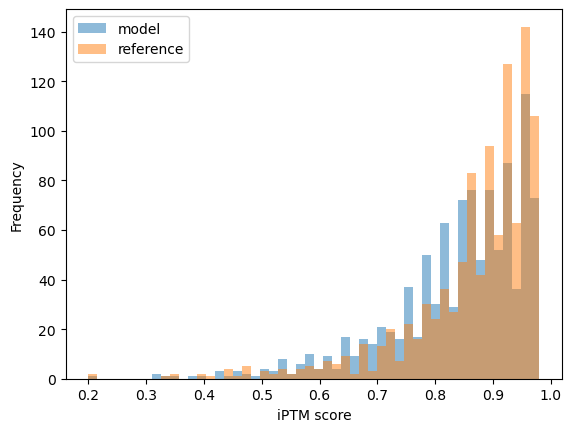

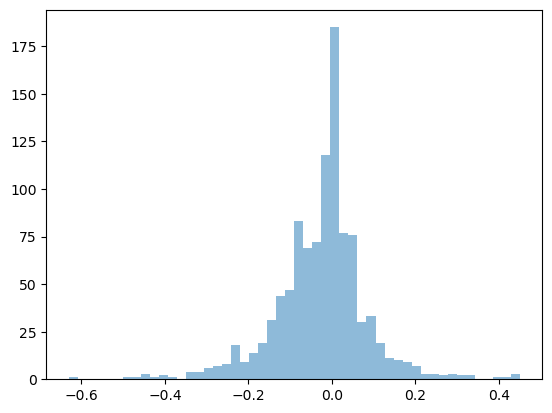

In [8]:
import numpy as np
import matplotlib.pyplot as plt

print(np.mean(model_iptms), np.mean(model_ptms), np.mean(reference_iptms), np.mean(reference_ptms), len(model_iptms))

plt.hist(model_iptms, bins=50, alpha=0.5, label='model')
plt.hist(reference_iptms, bins=50, alpha=0.5, label='reference')
plt.legend(loc='upper left')
plt.xlabel("iPTM score")
plt.ylabel("Frequency")
plt.show()

plt.hist(model_iptms-reference_iptms, bins=50, alpha=0.5, label='model-reference')
plt.show()

Spearson correlation SignificanceResult(statistic=0.07515581692355895, pvalue=0.01534144715480842)
Pearson correlation PearsonRResult(statistic=-0.02445779801363328, pvalue=0.43074957659557683)


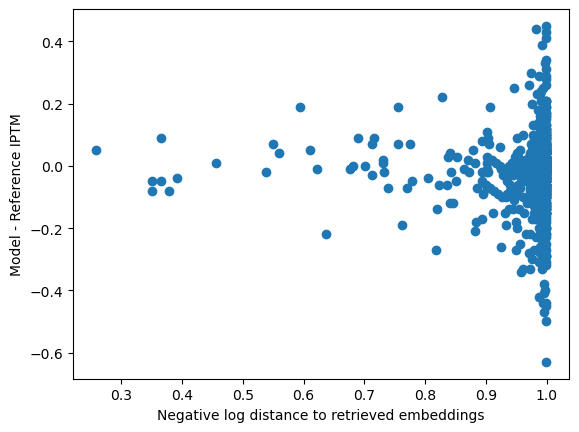

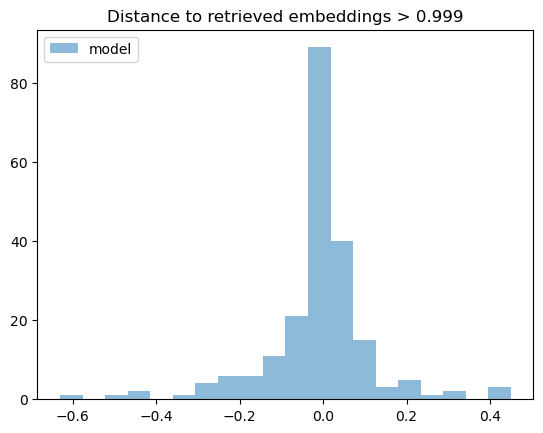

In [3]:
# does better performance correlate with distance to retreived embeddings

import pandas as pd
from scipy.stats import pearsonr, spearmanr
query_results_df = pd.read_csv("retrieved_embeddings/Pion_query_results.csv")
query_id_to_dist = {row['query_id'].lower():row['dist'] for i,row in query_results_df.iterrows()}
dists = [query_id_to_dist[x] for x in ids]
dists = np.array(dists)

iptm_diff = np.array(model_iptms) - np.array(reference_iptms)
print("Spearson correlation", spearmanr(dists, iptm_diff))
print("Pearson correlation", pearsonr(dists, iptm_diff))

plt.scatter(dists, iptm_diff)
plt.xlabel('Negative log distance to retrieved embeddings')
plt.ylabel('Model - Reference IPTM')
plt.show()

cutoff = 0.999
plt.hist(iptm_diff[dists > cutoff], bins=20, alpha=0.5, label='model')
# plt.hist(reference_iptms[dists < 0.01], bins=20, alpha=0.5, label='reference')
plt.legend(loc='upper left')
plt.title(f"Distance to retrieved embeddings > {cutoff}")
plt.show()


In [4]:
query_results_df['neighbour_ion'].value_counts(), query_results_df['random_ion'].value_counts()

(neighbour_ion
 MG    675
 ZN    224
 CA    192
 MN     51
 FE     28
 CO     15
 CU     11
 K       4
 Name: count, dtype: int64,
 random_ion
 CU    160
 K     156
 FE    154
 CA    142
 CO    139
 MN    129
 ZN    125
 MG     53
 Name: count, dtype: int64)

             iptm_diff
neigh_count           
1            -0.000513
2            -0.020282
3            -0.035269
4            -0.028989
5            -0.027478
neigh_count
1     39
2    355
3    353
4    178
5    115
dtype: int64


<Axes: xlabel='neigh_count', ylabel='iptm_diff'>

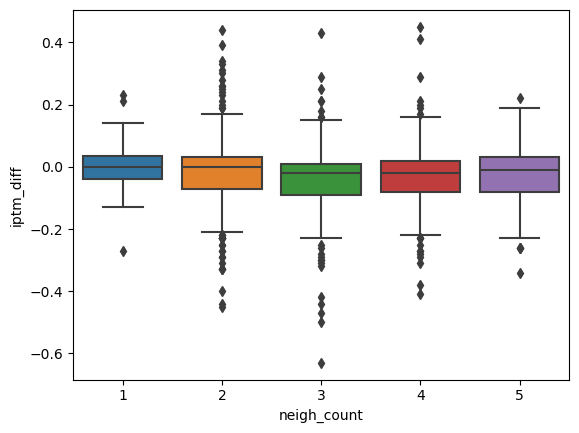

In [6]:
query_id_to_neigh_count = {row['query_id'].lower():row['neighbour_ion_count'] for i,row in query_results_df.iterrows()}
neigh_count = [query_id_to_neigh_count[x] for x in ids]

plot_data = pd.DataFrame({'neigh_count': neigh_count, 'iptm_diff': iptm_diff})
print(plot_data.groupby('neigh_count').mean())
print(plot_data.groupby('neigh_count').size())

import seaborn as sns
sns.boxplot(x='neigh_count', y='iptm_diff', data=plot_data)

# UMAP of the PESTO interfaces
see if there is separation between the interfaces

In [21]:
proj_2d = pd.read_csv('/n/holyscratch01/mzitnik_lab/afang/InteractNN_embeddings/version_149_epoch115_step1192946/is_dark_90_plddt_PeSTo_80_graph_embedding_2d.csv')
proj_2d['binder_type'] = proj_2d['id'].apply(lambda x: x.split('_')[-1])

In [22]:
proj_2d

,id,x_5,y_5,x_10,y_10,x_20,y_20,x_30,y_30,x_50,y_50,x_100,y_100,binder_type
0,A0A1F9ETZ8_ligand,-81.721161,47.045429,-64.358447,55.941098,-83.415106,21.391853,-79.430791,23.406533,-63.340403,12.594530,-43.711197,4.561678,ligand
1,A0A3D4FLL6_ligand,-82.123473,46.022721,-65.303715,55.321096,-84.690001,21.522877,-79.876560,22.261002,-64.907355,12.753632,-44.926627,4.353957,ligand
2,A0A543J756_ligand,-47.973768,3.614083,-53.272653,5.623795,-28.889085,5.837513,-43.735905,2.846231,-40.845768,-8.334733,-42.571661,-8.522856,ligand
3,A0A316AG42_ligand,-11.856186,-69.953854,-19.665522,-61.822152,-18.449475,-47.174769,-15.483757,-38.435161,-15.904614,-23.709064,-8.832607,-14.366713,ligand
4,A0A1I6TA50_ligand,23.036566,-30.844932,24.750676,-30.488294,20.755346,-29.424403,18.604938,-21.586181,17.106330,-15.874232,12.700682,-5.977627,ligand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4167,A0A2W5HCG4_protein,-75.562228,-8.183954,-79.851301,4.392235,-78.200804,2.799076,-69.061535,1.398213,-59.034828,1.007859,-39.526210,-2.601850,protein
4168,A0A2G7M0A6_protein,-21.972967,1.362727,-14.653950,15.219393,-15.482070,21.562505,-25.117158,4.263201,-19.933984,22.511150,-7.689504,-4.048282,protein
4169,S2D472_protein,-81.508016,-24.786483,-89.120472,-4.835349,-79.438250,-9.071338,-71.057639,-6.791752,-59.917898,-5.822123,-38.847242,-6.931321,protein
4170,A0A7V7VJV7_protein,-65.775725,-17.782163,-72.123798,-13.409786,-63.354772,-7.380895,-54.545005,-7.033621,-48.331795,-6.168822,-32.200645,-4.472945,protein


<Axes: xlabel='x_50', ylabel='y_50'>

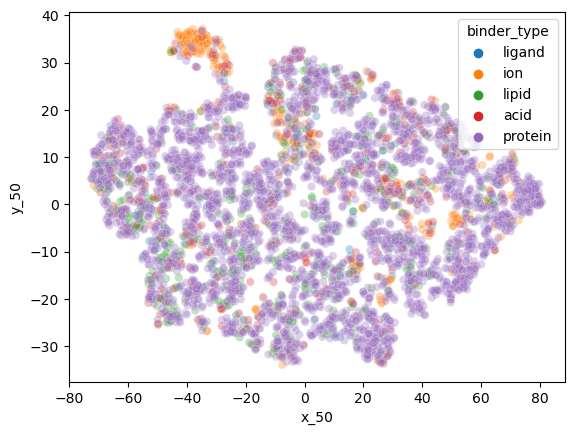

In [31]:
perplexity=50
sns.scatterplot(data=proj_2d, x=f'x_{perplexity}', y=f'y_{perplexity}', hue='binder_type', alpha=0.3)